## **ENIGH** - EDA Filtrado y Comparación de Modelos
* 18 de Marzo del 2025
#### ESCOM - IPN: *Modelado Predictivo*
#### Prof. Claudia Blanquel

#### *Lic. Ciencia de Datos* - 6AM1

> Armas Ramirez Daniel

> Gutierrez Ramirez Alana Sofia

> Hernández Peña Irving Jafet

> Reyes Maldonado Oscar Romario

> Sanchez Garcia Miguel Alexander

#### **0° Introducción**

Datos obtenidos de:

> https://www.inegi.org.mx/programas/enigh/nc/2016/#datos_abiertos

**a.** Como primer paso, necesitamos **importar** todas las **librerias** que usaremos

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
import seaborn as sns

import scipy.stats as stats

from sklearn.preprocessing import PowerTransformer

# For PCA
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import euclidean_distances

# For the random forest
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

# Realizar predicciones
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Para la regresión logística
from sklearn.linear_model import LogisticRegression


**b.** Extraer la tabla necesaria de la base de datos

In [17]:
concentradohogar_df = pd.read_csv('datasets-ENIGH/conjunto_de_datos_concentradohogar_enigh_2016_ns/conjunto_de_datos/conjunto_de_datos_concentradohogar_enigh_2016_ns.csv')

#### **1° Data Cleaning**

In [18]:
concentradohogar_df.head()

,folioviv,foliohog,ubica_geo,ageb,tam_loc,est_socio,est_dis,upm,factor,clase_hog,...,mater_serv,material,servicio,deposito,prest_terc,pago_tarje,deudas,balance,otras_erog,smg
0,100003801,1,10010000,000-0,1,4,3,10,248,2,...,98.36,98.36,0.00,0.0,0.0,17409.83,0.0,0.0,0.0,6573.6
1,100003802,1,10010000,000-0,1,4,3,10,248,2,...,0.00,0.00,0.00,0.0,0.0,5360.65,0.0,0.0,0.0,6573.6
2,100003803,1,10010000,000-0,1,4,3,10,248,2,...,172.13,0.00,172.13,0.0,0.0,23606.55,0.0,0.0,0.0,6573.6
3,100003804,1,10010000,000-0,1,4,3,10,248,3,...,0.00,0.00,0.00,0.0,0.0,8852.45,0.0,0.0,0.0,6573.6
4,100003805,1,10010000,000-0,1,4,3,10,248,2,...,0.00,0.00,0.00,0.0,0.0,0.00,0.0,0.0,0.0,6573.6


In [19]:
data = concentradohogar_df.copy()

# Crear columnas de ingreso total y gasto total
data['ingreso_total'] = data['ing_cor'] + data['percep_tot']
data['gasto_total'] = data['gasto_mon'] + data['erogac_tot']

# Crear la columna de endeudamiento (continua)
data['endeudamiento'] = data['gasto_total'] / data['ingreso_total']

# Crear la columna de endeudamiento (categórica)
def etiquetar_endeudamiento(endeudamiento):
    if endeudamiento < 0.95:
        return 'No endeudado'
    else:
        return 'En riesgo de endeudamiento'
    
# Aplicar la función de etiquetado a la columna de endeudamiento
data['endeudamiento'] = data['endeudamiento'].replace([np.inf, -np.inf], np.nan)  # Reemplazar inf y -inf con NaN
    
data['endeudamiento'] = data['endeudamiento'].apply(etiquetar_endeudamiento)

In [25]:
# Seleccionas solo las variables numéricas para el análisis
numericas = data.select_dtypes(include=[np.number]).copy()

# Agregar endeudamiento a las variables numéricas
numericas['endeudamiento'] = data['endeudamiento']

# Llevar a 0 y 1 endeudamiento
numericas['endeudamiento'] = numericas['endeudamiento'].map({'No endeudado': 0, 'En riesgo de endeudamiento': 1})

# Correlación entre las variables numéricas
correlacion = numericas.corr()

# Imprimir las correlaciones mayores a 0.1 y menores a -0.1 con la variable de endeudamiento
correlacion_endeudamiento = correlacion['endeudamiento'].sort_values(ascending=False)
print("Correlaciones con la variable de endeudamiento:")
print(correlacion_endeudamiento[correlacion_endeudamiento > 0.1])
print("\n")
print("Correlaciones negativas con la variable de endeudamiento:")
print(correlacion_endeudamiento[correlacion_endeudamiento < -0.09])


Correlaciones con la variable de endeudamiento:
endeudamiento    1.000000
alimentos        0.211601
gasto_mon        0.198951
ali_dentro       0.194395
cereales         0.143203
verduras         0.138710
educa_espa       0.136080
gasto_total      0.132299
educacion        0.123504
leche            0.118744
transporte       0.115681
carnes           0.115627
vesti_calz       0.113629
calzado          0.110909
ali_fuera        0.110893
alquiler         0.105569
Name: endeudamiento, dtype: float64


Correlaciones negativas con la variable de endeudamiento:
estim_alqu   -0.092344
transf_hog   -0.094985
ingtrab      -0.102430
edad_jefe    -0.108921
trabajo      -0.113719
sueldos      -0.117229
Name: endeudamiento, dtype: float64


**alimentos**: los gastos en bienes de consumo no duradero que realizan día a día los integrantes del hogar en alimentos, bebidas y tabaco.

**gasto_mon**: suma de los gastos regulares que directamente hacen los hogares en bienes y servicios para su consumo

**ali_dentro**: Gasto en alimentos y bebidas dentro del hogar

**cereales**: Gasto en cereales

**ingtrab**: Suma del ingreso obtenido por trabajo, como subordinado, como independiente y de otros trabajos

**edad_jefe**: Años transcurridos entre la fecha de nacimiento del jefe del hogar y la fecha de la entrevista

**trabajo**: Son las remuneraciones por trabajo subordinado. Esta compuesta por los sueldos, las comisiones, aguinaldo, indemnizaciones del trabajo y remuneraciones en especie

**sueldos**: Remuneraciones por sueldos, salarios y jornal.

In [ ]:
# Escoger las columnas relevantes
datos = data[['folioviv','ubica_geo', 'tam_loc', 'est_socio',
              'clase_hog', 'sexo_jefe', 'edad_jefe', 'educa_jefe', 'tot_integ', 'hombres', 'mujeres',
              'mayores', 'menores', 'p12_64', 'p65mas', 'ocupados', 'alimentos', 'balance', 'ali_dentro',
              'transf_hog', 'sueldos', 'endeudamiento']]

# Eliminar filas con valores nulos
datos = datos.dropna()

# Eliminar folioviv duplicados
datos = datos.drop_duplicates(subset='folioviv')

# Eliminar folioviv
datos = datos.drop(columns=['folioviv'])

datos.head()

,ubica_geo,tam_loc,est_socio,clase_hog,sexo_jefe,edad_jefe,educa_jefe,tot_integ,hombres,mujeres,...,p12_64,p65mas,ocupados,alimentos,balance,ali_dentro,transf_hog,sueldos,gasto_mon,endeudamiento
0,10010000,1,4,2,1,33,10,2,1,1,...,2,0,2,10621.89,0.0,9953.32,0.0,97377.04,46599.96,No endeudado
1,10010000,1,4,2,1,29,10,2,1,1,...,2,0,2,14637.70,0.0,6280.59,0.0,91475.40,82427.75,No endeudado
2,10010000,1,4,2,1,47,10,6,2,4,...,3,0,1,21214.07,0.0,13114.08,0.0,82622.95,54792.51,No endeudado
3,10010000,1,4,3,2,29,11,3,0,3,...,3,0,2,14567.00,0.0,9938.43,0.0,33442.61,42452.37,No endeudado
4,10010000,1,4,2,1,55,10,2,2,0,...,2,0,1,16097.03,0.0,10697.04,0.0,35409.83,47589.29,No endeudado


#### **3° Variables mas importantes**

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

# Verificar el numero de clases en la variable objetivo
print(datos['endeudamiento'].value_counts())

# Tomar una muestra del mismo tamaño de cada clase (el mínimo entre ambas)
min_count = min(
	datos[datos['endeudamiento'] == 'No endeudado'].shape[0],
	datos[datos['endeudamiento'] == 'En riesgo de endeudamiento'].shape[0]
)
datos_no_endeudado = datos[datos['endeudamiento'] == 'No endeudado'].sample(n=min_count, random_state=21)
datos_en_riesgo = datos[datos['endeudamiento'] == 'En riesgo de endeudamiento'].sample(n=min_count, random_state=21)

# Concatenar las muestras
datos = pd.concat([datos_no_endeudado, datos_en_riesgo], axis=0)
# Reiniciar el índice del DataFrame
datos = datos.reset_index(drop=True)
# Verificar el número de clases en la variable objetivo después de la muestra
print(datos['endeudamiento'].value_counts())

# Dividir los datos en características (X) y variable objetivo (y)
X = datos.drop('endeudamiento', axis=1)
y = datos['endeudamiento']
# Convertir las variables categóricas en variables dummy
X = pd.get_dummies(X, drop_first=True)
# Dividir los datos en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=21)
# Estandarizar las características
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

endeudamiento
No endeudado                  54277
En riesgo de endeudamiento    14892
Name: count, dtype: int64
endeudamiento
No endeudado                  14892
En riesgo de endeudamiento    14892
Name: count, dtype: int64


Características más importantes:
       feature  importance
19     sueldos    0.164681
20   gasto_mon    0.161265
15   alimentos    0.113274
17  ali_dentro    0.090981
5    edad_jefe    0.069175
0    ubica_geo    0.066921
18  transf_hog    0.050535
6   educa_jefe    0.035983
14    ocupados    0.027257
16     balance    0.026045


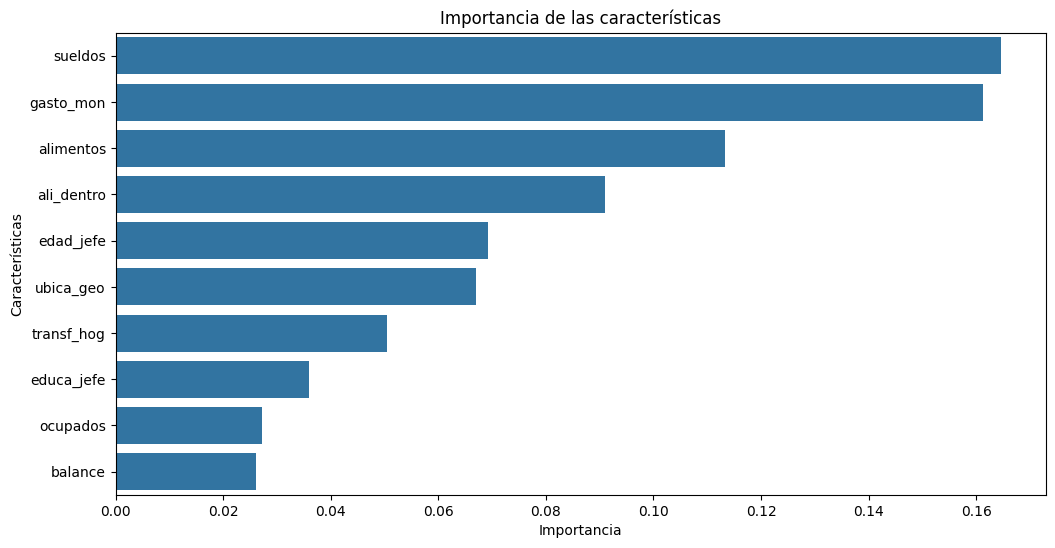

In [28]:
# Buscar las mejores características usando Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=21)
rf.fit(X_train_scaled, y_train)
# Obtener las importancias de las características
importances = rf.feature_importances_
# Crear un DataFrame para las importancias
feature_importances = pd.DataFrame({'feature': X.columns, 'importance': importances})
# Ordenar las importancias de mayor a menor
feature_importances = feature_importances.sort_values(by='importance', ascending=False)
# Mostrar las 10 características más importantes
print("Características más importantes:")
print(feature_importances.head(10))
# Graficar las importancias de las características
plt.figure(figsize=(12, 6))
sns.barplot(x='importance', y='feature', data=feature_importances.head(10))
plt.title('Importancia de las características')
plt.xlabel('Importancia')
plt.ylabel('Características')
plt.show()

In [ ]:
# Entrenar el modelo de regresión logística con las mejores características
best_features = feature_importances.head(8)['feature'].tolist()
# Quitar ali_dentro de las mejores características
best_features.remove('ali_dentro')
# Entrenar el modelo de regresión logística con las mejores características
X_train_best = X_train_scaled[:, [X.columns.get_loc(feature) for feature in best_features]]
X_test_best = X_test_scaled[:, [X.columns.get_loc(feature) for feature in best_features]]
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_best, y_train)
#Imprimir la ecuación del modelo
print("Ecuación del modelo de regresión logística:")
for i, feature in enumerate(best_features):
    coef = log_reg.coef_[0][i]
    print(f"{coef:.4f} * {feature}", end=' + ')
print(f"{log_reg.intercept_[0]:.4f}")
# Realizar predicciones
y_pred = log_reg.predict(X_test_best)
# Evaluar el modelo
print("Reporte de clasificación:")
print(classification_report(y_test, y_pred))
# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=log_reg.classes_, yticklabels=log_reg.classes_)
plt.title('Matriz de confusión')
plt.xlabel('Predicción')
plt.ylabel('Realidad')
plt.show()

NameError: name 'feature_importances' is not defined

In [208]:
# Entrenar el modelo de random forest con las mejores características
rf_best = RandomForestClassifier(n_estimators=100, random_state=42)
rf_best.fit(X_train_best, y_train)
# Realizar predicciones
y_pred_rf = rf_best.predict(X_test_best)
# Evaluar el modelo
print("Reporte de clasificación (Random Forest):")
print(classification_report(y_test, y_pred_rf))

Reporte de clasificación (Random Forest):
                            precision    recall  f1-score   support

En riesgo de endeudamiento       0.75      0.83      0.79      4469
              No endeudado       0.81      0.72      0.76      4467

                  accuracy                           0.78      8936
                 macro avg       0.78      0.78      0.78      8936
              weighted avg       0.78      0.78      0.78      8936

